<a href="https://colab.research.google.com/github/wuba2010work/CWP/blob/main/WaPORmonthly%20ETa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install rioxarray --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.7 MB/s eta 0:00:00


In [2]:
import os
import glob
import datetime
import xarray as xr
import rioxarray as rio
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


In [3]:
#To upload file.
uploaded = files.upload()

Saving Amib ETa_2025_100m_WaPOR.zip to Amib ETa_2025_100m_WaPOR.zip


In [4]:
# unzip the uploaded zipfile
!unzip '/content/Amib ETa_2025_100m_WaPOR.zip' -d '/content/'

Archive:  /content/Amib ETa_2025_100m_WaPOR.zip
   creating: /content/content/output/
   creating: /content/content/output/L2-AETI-D/
  inflating: /content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-05-21.tif  
  inflating: /content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-11-21.tif  
  inflating: /content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-04-01.tif  
  inflating: /content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-01-21.tif  
  inflating: /content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-12-11.tif  
  inflating: /content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-09-11.tif  
  inflating: /content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-06-01.tif  
  inflating: /content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_

In [11]:
# Open first raster from your unzipped files and mask out nan values
ds = rio.open_rasterio('/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-09-21.tif')
ds = ds.where(ds!=ds.attrs['_FillValue'])

In [12]:
# Inspect the contents - How many pixels does the raster contain?
ds

<xarray.DataArray (band: 1, y: 239, x: 161)> Size: 308kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 2kB 9.462 9.461 9.46 9.459 ... 9.232 9.231 9.23
  * x            (x) float64 1kB 40.1 40.1 40.1 40.1 ... 40.25 40.25 40.25 40.25
    spatial_ref  int64 8B 0
Attributes: (12/13)
    AREA_OR_POINT:            Area
    end_date:                 2025-09-30
    long_name:                2025-09-21
    number_of_days:           10
    original_units:           mm/day
    overview:                 NONE
    ...                       ...
    temporal_resolution:      Dekad
    units:                    mm/dekad
    units_conversion_factor:  10
    _FillValue:               -9999.0
    scale_factor:             1.0
    add_offset:               0.0

In [13]:
#The values contained are stored as an array with each value representing one pixel.
ds.values

array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])

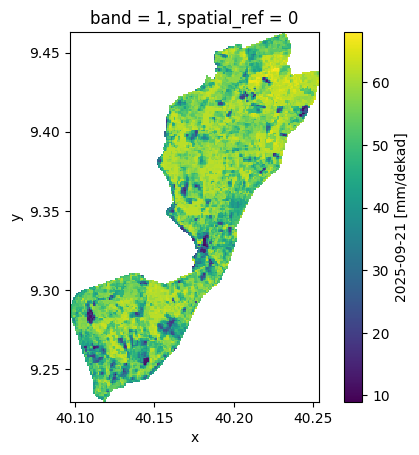

In [14]:
# We can produce a quick map of our data using the plot function
ds[0].plot()
ax = plt.gca()
ax.set_aspect('equal', adjustable='box') #this command will equally space the x and y units

In [15]:
#check the min, max and mean values
print(np.nanmin(ds.values), np.nanmax(ds.values), np.nanmean(ds.values))

9.0 68.0 53.07553983344388


In [16]:
# seasonal AETI from Dekadal ETa
glob.glob('/content/content/output/L2-AETI-D/*.tif')

['/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-05-21.tif',
 '/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-11-21.tif',
 '/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-04-01.tif',
 '/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-01-21.tif',
 '/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-12-11.tif',
 '/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-09-11.tif',
 '/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-06-01.tif',
 '/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-04-11.tif',
 '/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-02-21.tif',
 '/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_convert

In [18]:
glob.glob('/content/content/output/L2-AETI-D/*2025-05*.tif')

['/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-05-21.tif',
 '/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-05-11.tif',
 '/content/content/output/L2-AETI-D/Amibara_JSON.json_L2-AETI-D_NONE_dekad_converted_2025-05-01.tif']

In [19]:
for i, fp in enumerate(glob.glob('/content/content/output/L2-AETI-D/*2025-05*.tif')):
  fn = os.path.basename(fp)
  # OPEN DATA
  ds = rio.open_rasterio(fp)
  ds = ds.where(ds!=ds.attrs['_FillValue'])
  if i == 0:
    ds_sum = ds #Initialize sum if we are looking at the first raster
  else:
    ds_sum += ds #This is the python way of writing ds_sum = ds_sum + ds

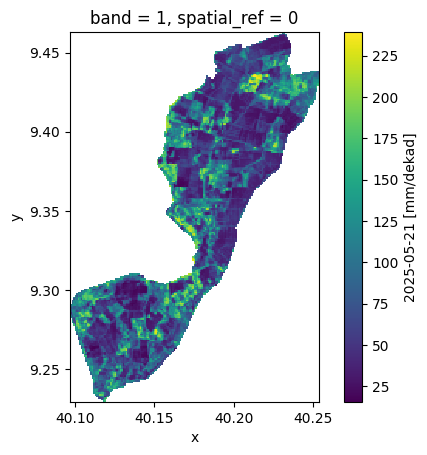

In [20]:
ds_sum.plot()
ax = plt.gca()
ax.set_aspect('equal', adjustable='box') #this command will equally space the x and y units

In [21]:
#Inspect Attributes to see which ones we will update
attrs = ds_sum.attrs
attrs

{'AREA_OR_POINT': 'Area',
 'end_date': '2025-05-31',
 'long_name': '2025-05-21',
 'number_of_days': 11,
 'original_units': 'mm/day',
 'overview': 'NONE',
 'start_date': '2025-05-21',
 'temporal_resolution': 'Dekad',
 'units': 'mm/dekad',
 'units_conversion_factor': 11,
 '_FillValue': np.float64(-9999.0),
 'scale_factor': 1.0,
 'add_offset': 0.0}

In [22]:
attrs.update({'start_date': '2025-05-01',
              'end_date': '2025-05-31',
              'units' : 'mm/month'})
del attrs['number_of_days']

ds_sum.attrs  = attrs

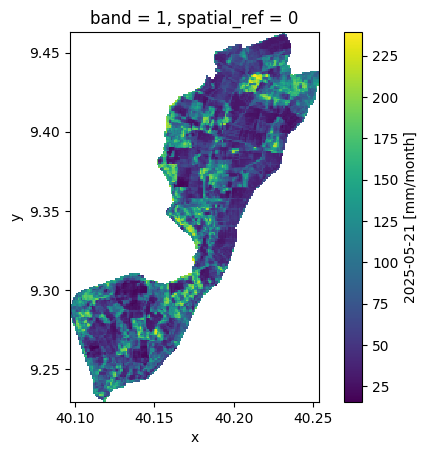

In [23]:
ds_sum.plot()
ax = plt.gca()
ax.set_aspect('equal', adjustable='box') #this command will equally space the x and y units

In [24]:
# Compute statistics for the monthly ETa raster
monthly_min = float(ds_sum.min().values)
monthly_max = float(ds_sum.max().values)
monthly_mean = float(ds_sum.mean().values)

print(f"Monthly ETa (May 2025) statistics:")
print(f"Min: {monthly_min:.2f} mm/month")
print(f"Max: {monthly_max:.2f} mm/month")
print(f"Mean: {monthly_mean:.2f} mm/month")

Monthly ETa (May 2025) statistics:
Min: 15.60 mm/month
Max: 239.20 mm/month
Mean: 80.85 mm/month
